In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("final_cleaned_dataset.csv")
print(df.head())

   area_sqft  bedrooms  bathrooms  floors  property_age  renovation_status  \
0       1710         3        2.5       2            23                  0   
1       1262         3        2.0       1            50                  0   
2       1786         3        2.5       2            25                  1   
3       1717         3        1.0       2           111                  1   
4       2198         4        2.5       2            26                  0   

   lot_size  distance_city_km  neighborhood_score  crime_rate_index  ...  \
0      8450              4.72                 6.9               2.3  ...   
1      9600              4.66                 5.4               4.7  ...   
2     11250              6.27                 6.9               2.8  ...   
3      9550              6.30                 6.6               2.9  ...   
4     14260              6.90                 7.7               2.1  ...   

   green_space_index  flood_risk_index  noise_pollution_level  SalePrice  

In [2]:
print("LINEAR _REGRESSION  without log tranformation")

LINEAR _REGRESSION  without log tranformation


 Test R2: 0.8065400503162407
MAE: 21197.04680371217
RMSE: 30690.65553741355


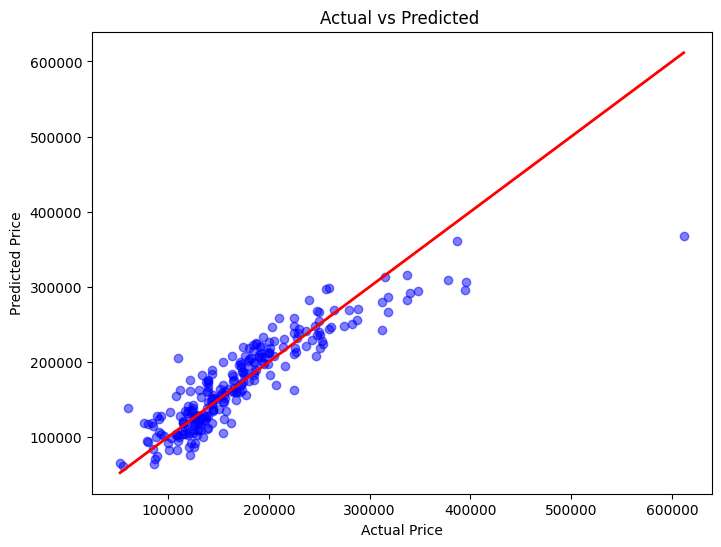

In [3]:

X = df.drop('SalePrice', axis=1)
y = df['SalePrice'] 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_raw = LinearRegression()
lr_raw.fit(X_train, y_train)


y_pred = lr_raw.predict(X_test)

# Evaluation
print(f" Test R2: {r2_score(y_test, y_pred):}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted ")
plt.show()

In [4]:
train_pred = lr_raw.predict(X_train)
print("Model Performance (No Log Transform) ---")
print(f"Train R2: {r2_score(y_train, train_pred):}")
print(f"Test R2:  {r2_score(y_test, y_pred):}")

Model Performance (No Log Transform) ---
Train R2: 0.8354707634772782
Test R2:  0.8065400503162407


In [5]:
print("LINEAR REGRESSION WITH LOG TRANSFORMATION")

LINEAR REGRESSION WITH LOG TRANSFORMATION


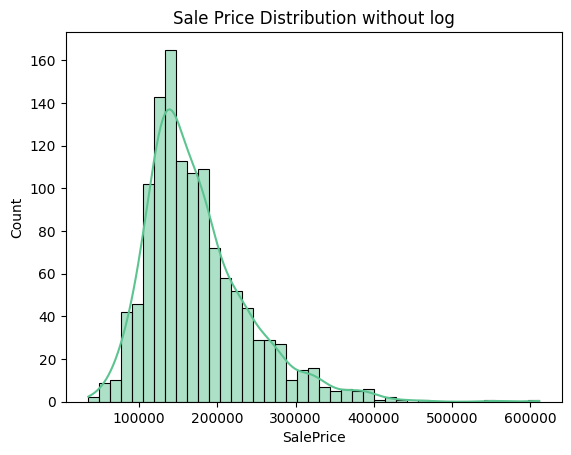

In [6]:
sns.histplot(df["SalePrice"], kde = True, color = '#5cc490')
plt.title("Sale Price Distribution without log")
plt.show()

In [7]:
y_log = np.log1p(df['SalePrice']) 


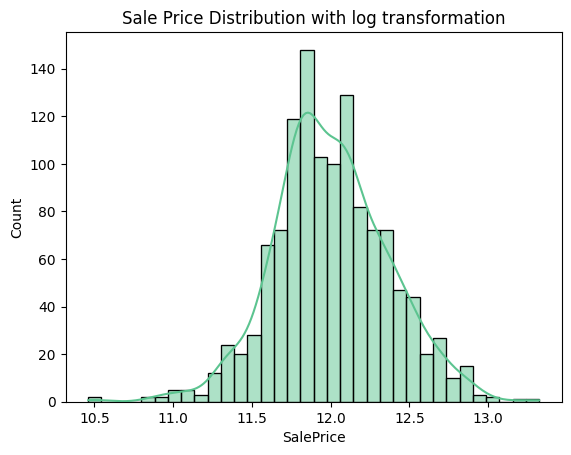

In [8]:
sns.histplot(y_log, kde = True, color = '#5cc490')
plt.title("Sale Price Distribution with log transformation")
plt.show()

R2 Score: 0.8532693662545658
Actual MAE: 18622.867749131405
MSE: 26728.280863336524


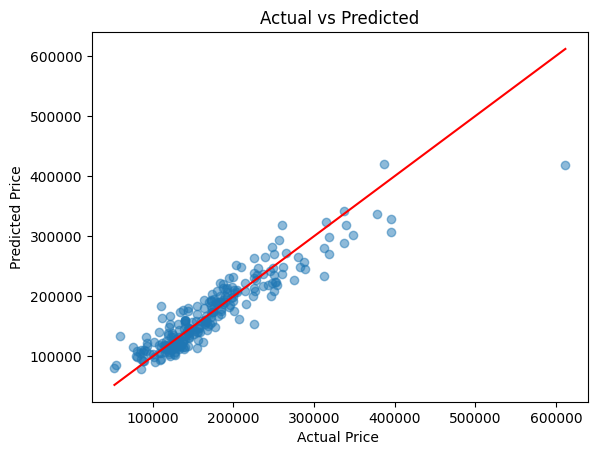

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error


X = df.drop('SalePrice', axis=1)

# log transformation
y_log = np.log1p(df['SalePrice']) 

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)


lr = LinearRegression()
lr.fit(X_train, y_train_log)


y_pred_log = lr.predict(X_test)

# CONVERT 
y_train_original = np.expm1(y_train_log)
y_test_original = np.expm1(y_test_log)
y_pred_original = np.expm1(y_pred_log)

#  Evaluation
print(f"R2 Score: {r2_score(y_test_original, y_pred_original):}")
print(f"Actual MAE: {mean_absolute_error(y_test_original, y_pred_original):}")
print("MSE:", np.sqrt(mean_squared_error(y_test_original, y_pred_original)))

# linear regression
plt.scatter(y_test_original, y_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], color='red')
plt.xlabel("Actual Price ")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [10]:
train_pred_log = lr.predict(X_train)
train_pred = np.expm1(train_pred_log)

train_r2 = r2_score(y_train_original, train_pred)
test_r2 = r2_score(y_test_original, y_pred_original)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.8686121165737715
Test R2: 0.8532693662545658


In [11]:
print("backward feature elimination for linear regreesion(log) models")

backward feature elimination for linear regreesion(log) models


In [12]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# 1. Initialize RFE for the Log Model
# We use the raw X_train_scaled but fit against y_train_log
lr_log_selector = RFE(estimator=LinearRegression(), n_features_to_select=15, step=1)
lr_log_selector.fit(X_train_scaled, y_train_log)

# 2. Filter features
X_train_log_rfe = lr_log_selector.transform(X_train_scaled)
X_test_log_rfe = lr_log_selector.transform(X_test_scaled)

# 3. Re-train the Log Model
lr_log_final = LinearRegression()
lr_log_final.fit(X_train_log_rfe, y_train_log)

# 4. Predict and Convert back from Log scale to Dollars
pred_log = lr_log_final.predict(X_test_log_rfe)
pred_final_dollars = np.expm1(pred_log)

# 5. Evaluate
log_r2 = r2_score(y_test_original, pred_final_dollars)
log_mae = mean_absolute_error(y_test_original, pred_final_dollars)

print("--- Linear (Log) After Backward Selection ---\n")

print(f"Features Kept: {X.columns[lr_log_selector.support_].tolist()}")
print("\n")
print(f"New Test R2: {log_r2:.4f}")
print(f"New MAE: ${log_mae:,.2f}")



--- Linear (Log) After Backward Selection ---

Features Kept: ['area_sqft', 'bedrooms', 'bathrooms', 'floors', 'property_age', 'renovation_status', 'lot_size', 'neighborhood_score', 'school_rating', 'parking_availability', 'construction_quality', 'water_supply_score', 'green_space_index', 'Fireplaces', 'property_type_Duplex']


New Test R2: 0.8533
New MAE: $18,541.37


In [14]:
print("RANDOM FOREST REGRESSION")

RANDOM FOREST REGRESSION


 Random Forest Performance
Train R2: 0.9753759008561677
Test R2:  0.8005363274696408
MAE:      19908.41568548387
RMSE:     31163.23503145806


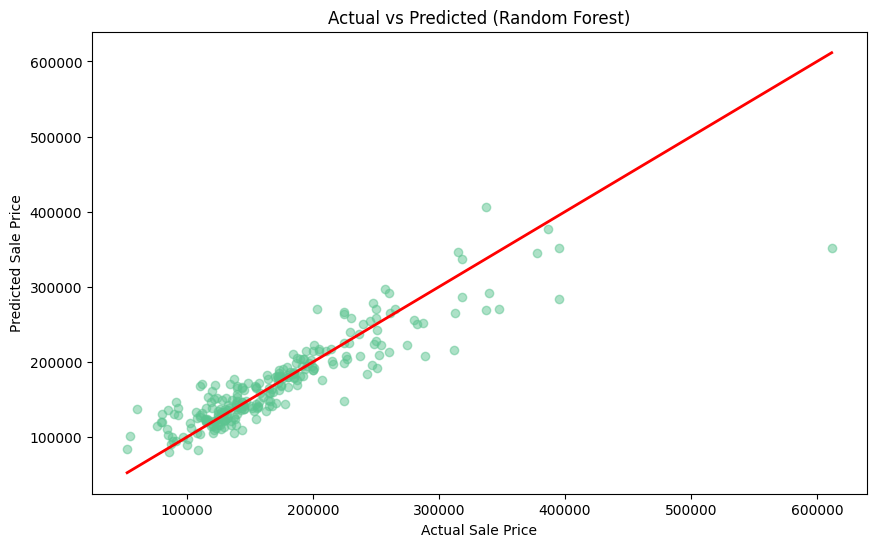

In [15]:
from sklearn.ensemble import RandomForestRegressor


X = df.drop('SalePrice', axis=1)
y = df['SalePrice'] 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)


train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)


print(" Random Forest Performance")
print(f"Train R2: {r2_score(y_train, train_pred):}")
print(f"Test R2:  {r2_score(y_test, test_pred):}")
print(f"MAE:      {mean_absolute_error(y_test, test_pred):}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, test_pred)):}")


plt.figure(figsize=(10, 6))
plt.scatter(y_test, test_pred, alpha=0.5, color='#5cc490')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()



In [16]:
print("SUPPORT VECTOR REGRESSION")

SUPPORT VECTOR REGRESSION


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR


# seperation of feature and target
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Scaling
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scaling Target 
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()


svr = SVR(kernel='rbf', C=1000, epsilon=0.1) 
svr.fit(X_train_scaled, y_train_scaled)


train_pred_scaled = svr.predict(X_train_scaled)
test_pred_scaled = svr.predict(X_test_scaled)


train_pred = scaler_y.inverse_transform(train_pred_scaled.reshape(-1, 1)).flatten()
svr_test_pred = scaler_y.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()


print("--- SVR Performance ---")
print(f"Train R2: {r2_score(y_train, train_pred):.4f}")
print(f"Test R2:  {r2_score(y_test, svr_test_pred):.4f}")
print(f"MAE:      {mean_absolute_error(y_test, svr_test_pred):,.2f}")

--- SVR Performance ---
Train R2: 0.9915
Test R2:  0.7739
MAE:      24,025.96


In [18]:
print("Ridge Regression")

Ridge Regression


In [19]:
from sklearn.linear_model import Ridge

#  fit
ridge = Ridge(alpha=1.0) 
ridge.fit(X_train, y_train)

# Predict and Evaluate
ridge_train_pred = ridge.predict(X_train)
ridge_test_pred = ridge.predict(X_test)

print("--- Ridge Regression Performance ---")
print(f"Train R2: {r2_score(y_train, ridge_train_pred):.4f}")
print(f"Test R2: {r2_score(y_test, ridge_test_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, ridge_test_pred):.2f}")

--- Ridge Regression Performance ---
Train R2: 0.8355
Test R2: 0.8062
MAE: 21195.43


In [20]:
print("Decision Tree")

Decision Tree


--- Decision Tree Performance ---
Train R2: 0.7454
Test R2: 0.7108
MAE: 25350.56


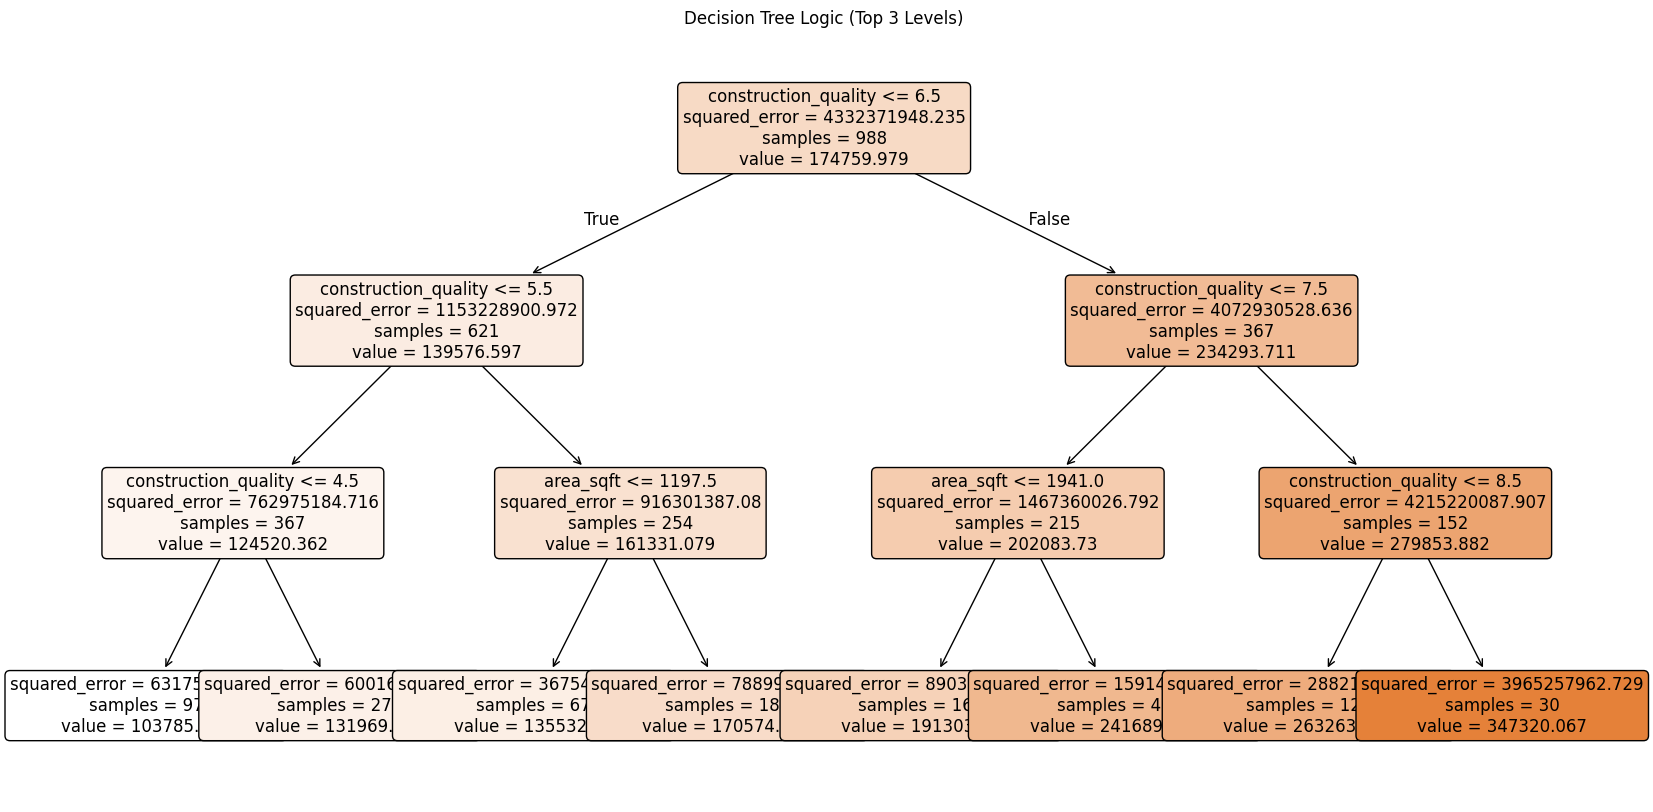

In [21]:
from sklearn.tree import DecisionTreeRegressor, plot_tree


dt = DecisionTreeRegressor(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

# Predict and Evaluate
dt_test_pred = dt.predict(X_test)

print("--- Decision Tree Performance ---")
print(f"Train R2: {r2_score(y_train, dt.predict(X_train)):.4f}")
print(f"Test R2: {r2_score(y_test, dt_test_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, dt_test_pred):.2f}")


# Tree
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, filled=True, rounded=True, fontsize=12)
plt.title("Decision Tree Logic (Top 3 Levels)")
plt.show()

In [22]:
print("Lasso Regression")

Lasso Regression


In [23]:
from sklearn.linear_model import Lasso

# fit
lasso = Lasso(alpha=0.1) 
lasso.fit(X_train, y_train)

# Predict and Evaluate
lasso_train_pred = lasso.predict(X_train)
lasso_test_pred = lasso.predict(X_test)

print("--- Lasso Regression Performance ---")
print(f"Train R2: {r2_score(y_train, lasso_train_pred):.4f}")
print(f"Test R2: {r2_score(y_test, lasso_test_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, lasso_test_pred):.2f}")


--- Lasso Regression Performance ---
Train R2: 0.8355
Test R2: 0.8065
MAE: 21196.90


In [24]:
print("backward feature elimination for all models")

backward feature elimination for all models


In [25]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import pandas as pd

# 1. Define models
# For SVR, we use a linear kernel for the 'ranking' phase of RFE
models_to_tune = {
    'Linear (Raw)': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR_Base': SVR(kernel='linear') 
}

# 2. Loop for Feature Selection (Reducing 29 features to top 15)
n_features = 15
optimized_results = {}

for name, model in models_to_tune.items():
    print(f"Selecting features for {name}...")
    
    # Initialize RFE
    selector = RFE(estimator=model, n_features_to_select=n_features, step=1)
    
    # Use scaled data for consistency (Required for SVR/Linear/Ridge)
    selector.fit(X_train_scaled, y_train_scaled)
    
    # Filter the features
    X_train_rfe = selector.transform(X_train_scaled)
    X_test_rfe = selector.transform(X_test_scaled)
    
    # Re-train the actual model on selected features
    # (If it's SVR, we switch back to the 'rbf' kernel for the actual prediction)
    if 'SVR' in name:
        final_model = SVR(kernel='rbf', C=1000, epsilon=0.1, gamma='auto')
    else:
        final_model = model
        
    final_model.fit(X_train_rfe, y_train_scaled)
    
    # Predict and Inverse Scale
    pred_scaled = final_model.predict(X_test_rfe)
    pred_final = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    
    # Store Results
    optimized_results[name] = {
        'R2': r2_score(y_test, pred_final),
        'MAE': mean_absolute_error(y_test, pred_final),
        'Features': X.columns[selector.support_].tolist()
    }

# 3. Display Comparison
res_df = pd.DataFrame(optimized_results).T[['R2', 'MAE']]
print("\n--- Performance After Backward Selection ---")
print(res_df)

Selecting features for Linear (Raw)...
Selecting features for Ridge...
Selecting features for Lasso...
Selecting features for Random Forest...
Selecting features for SVR_Base...

--- Performance After Backward Selection ---
                     R2           MAE
Linear (Raw)   0.805953  21143.315137
Ridge           0.80581  21137.697589
Lasso          0.722018  23272.115649
Random Forest  0.787291  20196.389153
SVR_Base       0.712318  27547.442818


In [26]:
print("Comparision of Models")

Comparision of Models


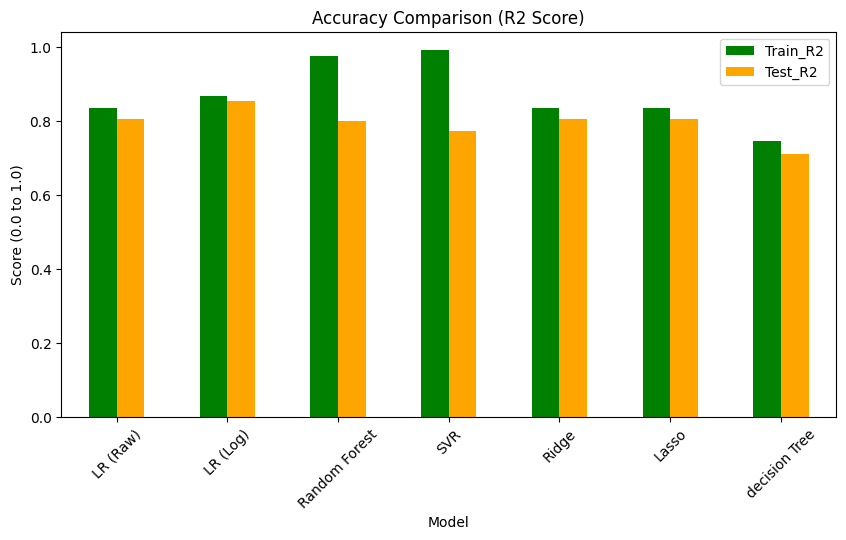

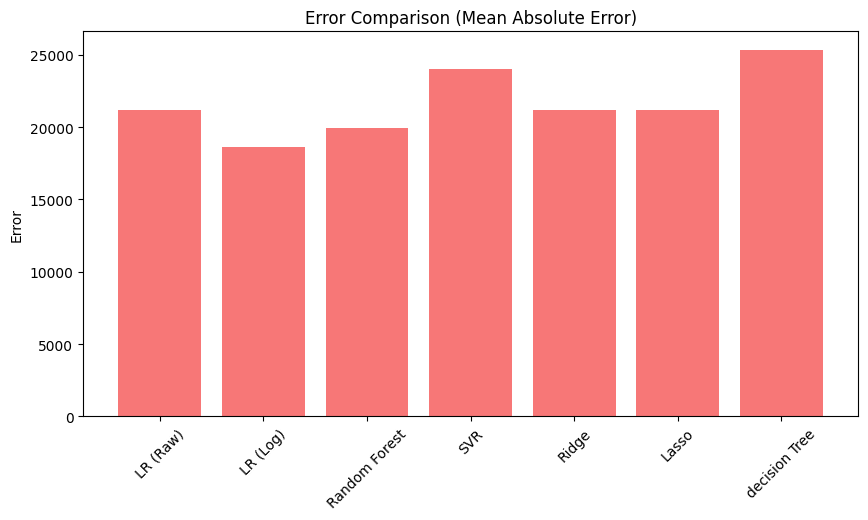

In [27]:


data = {
    'Model': ['LR (Raw)', 'LR (Log)', 'Random Forest', 'SVR', 'Ridge', 'Lasso',"decision Tree"],
    'Train_R2': [0.835, 0.868, 0.975, 0.991, 0.835, 0.835,0.7454],
    'Test_R2': [0.806, 0.853, 0.800, 0.773, 0.806, 0.806,0.7108],
    'MAE': [21197, 18622, 19908, 24025, 21195, 21196,25350]
}


df_results = pd.DataFrame(data)


df_results.plot(x='Model', y=['Train_R2', 'Test_R2'], kind='bar', figsize=(10, 5), color=['green', 'orange'])
plt.title('Accuracy Comparison (R2 Score)')
plt.ylabel('Score (0.0 to 1.0)')
plt.xticks(rotation=45)
plt.show()

#  Plotting the MAE (Lower is better)
plt.figure(figsize=(10, 5))
plt.bar(df_results['Model'], df_results['MAE'], color='#f77777')
plt.title('Error Comparison (Mean Absolute Error)')
plt.ylabel('Error')
plt.xticks(rotation=45)
plt.show()

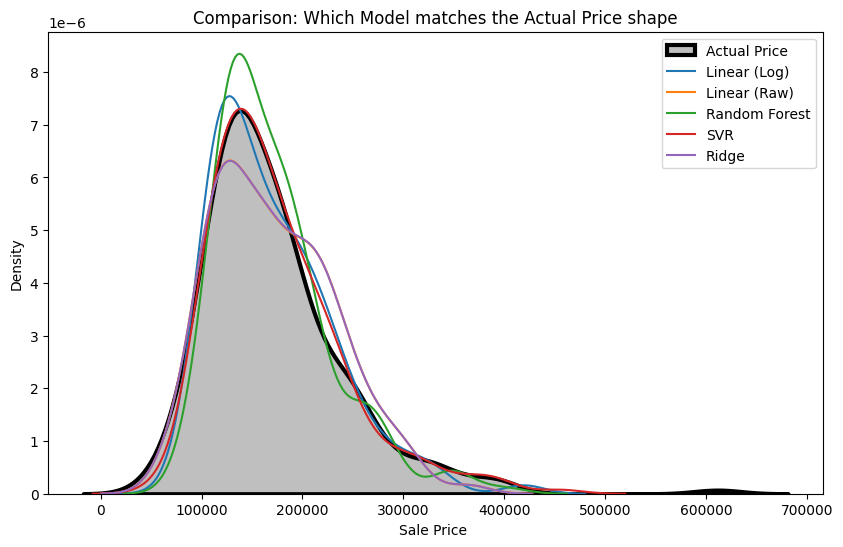

In [28]:
plt.figure(figsize=(10, 6))

sns.kdeplot(y_test_original, label='Actual Price', fill=True, color='black', lw=3)

all_predictions = {
    'Linear (Log)': y_pred_original,
    'Linear (Raw)': y_pred,
    'Random Forest': rf.predict(X_test),
    'SVR': svr_test_pred,
    'Ridge': ridge_test_pred
}

for name, data in all_predictions.items():
    sns.kdeplot(data, label=name)


plt.title('Comparison: Which Model matches the Actual Price shape')
plt.xlabel('Sale Price ')
plt.ylabel('Density')
plt.legend()
plt.show()

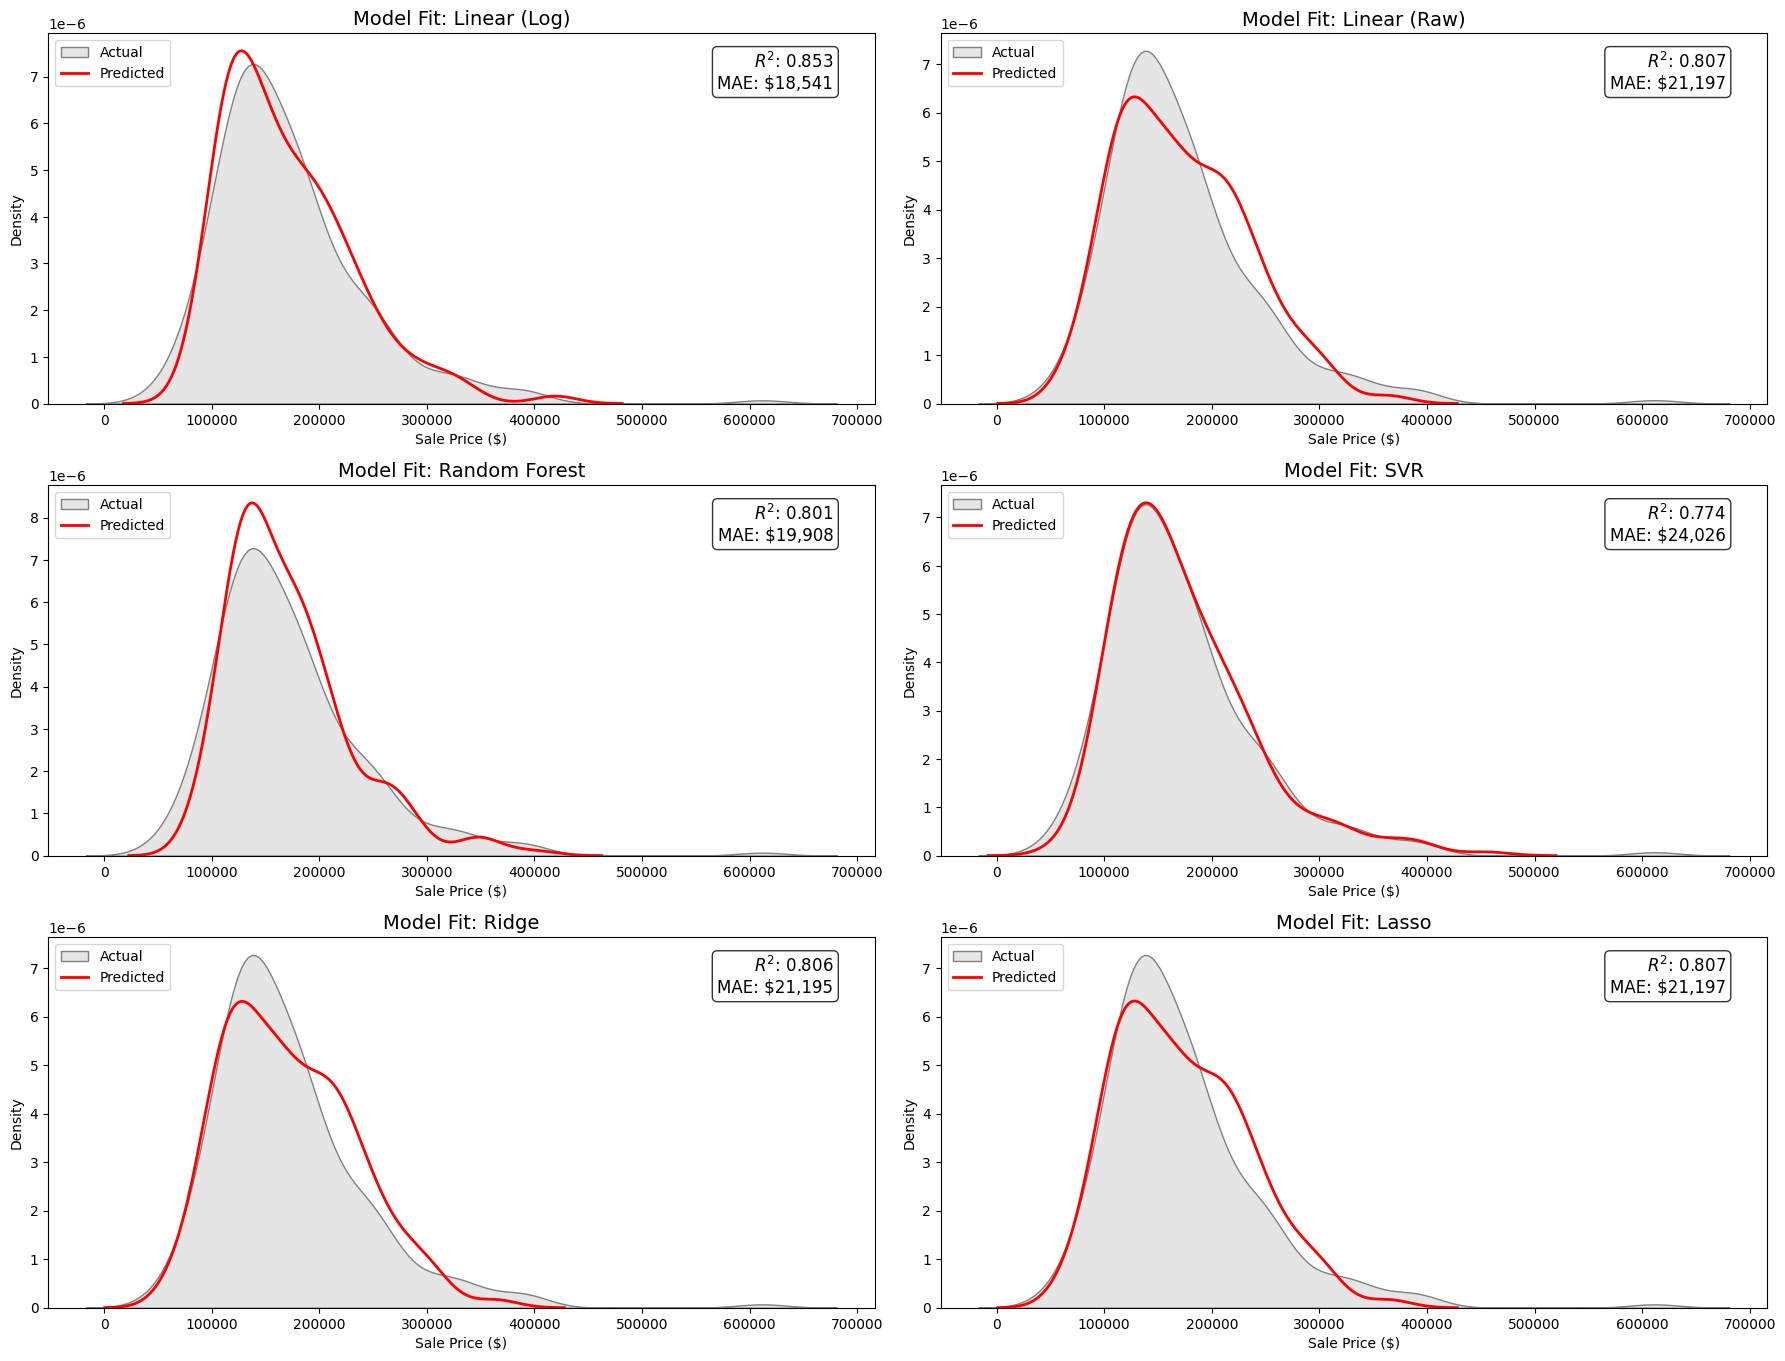

In [30]:
fig = plt.figure(figsize=(18, 18))
gs = fig.add_gridspec(4, 2) 

axes_sub = [fig.add_subplot(gs[i, j]) for i in range(1, 4) for j in range(2)]

for i, (name, pred_data) in enumerate(all_predictions.items()):
    ax = axes_sub[i]
    
  
    r2 = r2_score(y_test_original, pred_data)
    mae = mean_absolute_error(y_test_original, pred_data)
    

    sns.kdeplot(y_test_original, ax=ax, label='Actual', fill=True, color='gray', alpha=0.2)
    sns.kdeplot(pred_data, ax=ax, label='Predicted', color='red', lw=2)
    
    # Add Text
    stats_text = f"$R^2$: {r2:.3f}\nMAE: ${mae:,.0f}"
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='right', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title(f'Model Fit: {name}', fontsize=14)
    ax.legend(loc='upper left')
    ax.set_ylabel('Density')
    ax.set_xlabel('Sale Price ($)')

plt.tight_layout()
plt.show()